# Software Defect Prediction with Random Forest

Alternative approach using **Random Forest** with a simple train/test split and SMOTE oversampling. No K-Fold, no XGBoost — just a straightforward Random Forest pipeline with Optuna hyperparameter tuning optimized for F1.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import optuna
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
print("Libraries imported.")

Libraries imported.


/home/paul/Documents/00-git-uni/cassino-ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and Combine Training Data

In [2]:
dataset_paths = {
    "CM1": "datasets/datasets/cm1.csv",
    "JM1": "datasets/datasets/jm1.csv",
    "KC1": "datasets/datasets/kc1.csv",
    "PC1": "datasets/datasets/pc1.csv",
}

FEATURE_COLS = [
    "loc", "v(g)", "ev(g)", "iv(g)", "n", "v", "l", "d", "i", "e", "b", "t",
    "locode", "locomment", "loblank", "loccodeandcomment",
    "uniq_op", "uniq_opnd", "total_op", "total_opnd", "branchcount",
]

frames = []
for name, path in dataset_paths.items():
    df = pd.read_csv(path, skiprows=[1, 2])
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "")
    df["defects"] = df["defects"].map({"true": 1, "false": 0, True: 1, False: 0}).astype(int)
    frames.append(df)
    print(f"{name}: {len(df)} rows")

combined = pd.concat(frames, ignore_index=True)
X = combined[FEATURE_COLS].apply(pd.to_numeric, errors="coerce").fillna(combined[FEATURE_COLS].median())
y = combined["defects"]
print(f"\nCombined: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Class distribution: {dict(y.value_counts())}")

CM1: 496 rows
JM1: 13202 rows
KC1: 2107 rows
PC1: 1107 rows

Combined: 16912 rows, 21 features
Class distribution: {0: np.int64(14361), 1: np.int64(2551)}


## 3. Train/Test Split + SMOTE

In [3]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# SMOTE on training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Train: {len(X_train)} -> {len(X_train_res)} after SMOTE")
print(f"Test:  {len(X_test)} (untouched)")
print(f"Train class balance after SMOTE: {dict(pd.Series(y_train_res).value_counts())}")

Train: 13529 -> 22976 after SMOTE
Test:  3383 (untouched)
Train class balance after SMOTE: {0: np.int64(11488), 1: np.int64(11488)}


## 4. Baseline Random Forest

In [4]:
rf_baseline = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_baseline.fit(X_train_res, y_train_res)

y_pred = rf_baseline.predict(X_test)
y_proba = rf_baseline.predict_proba(X_test)[:, 1]

print("Baseline Random Forest:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1:       {f1_score(y_test, y_pred):.4f}")
print(f"  AUC:      {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Clean", "Buggy"]))

Baseline Random Forest:
  Accuracy: 0.8256
  F1:       0.4316
  AUC:      0.7961

              precision    recall  f1-score   support

       Clean       0.90      0.89      0.90      2873
       Buggy       0.42      0.44      0.43       510

    accuracy                           0.83      3383
   macro avg       0.66      0.67      0.66      3383
weighted avg       0.83      0.83      0.83      3383



## 5. Optuna Hyperparameter Tuning (Optimizing F1)

In [5]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }
    
    rf = RandomForestClassifier(
        **params, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(X_train_res, y_train_res)
    
    y_pred = rf.predict(X_test)
    return f1_score(y_test, y_pred)

study = optuna.create_study(direction="maximize", study_name="rf_f1_opt")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nBest F1: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 69. Best value: 0.455067: 100%|██████████| 100/100 [08:32<00:00,  5.13s/it]


Best F1: 0.4551
Best params:
  n_estimators: 490
  max_depth: 29
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  criterion: entropy


## 6. Threshold Optimization

Optimal threshold: 0.41
F1 at optimal threshold: 0.4707
F1 at default 0.5: 0.4551


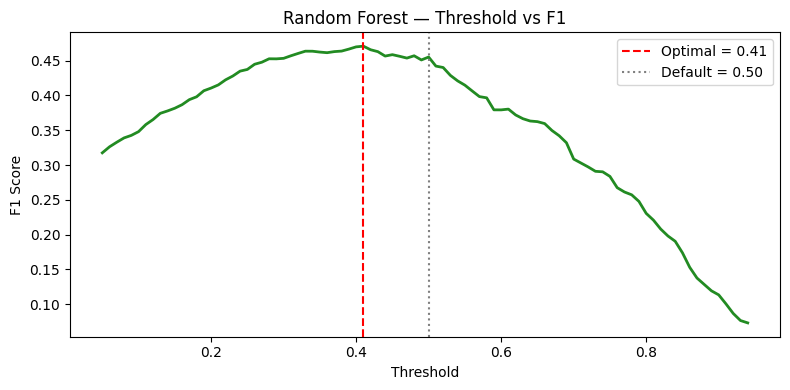

In [6]:
# Train best model and find optimal threshold
best_rf = RandomForestClassifier(
    **study.best_params, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
best_rf.fit(X_train_res, y_train_res)
test_proba = best_rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_test, (test_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"F1 at optimal threshold: {best_f1:.4f}")
print(f"F1 at default 0.5: {f1_score(y_test, (test_proba >= 0.5).astype(int)):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color="forestgreen", linewidth=2)
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Optimal = {best_threshold:.2f}")
plt.axvline(x=0.5, color="gray", linestyle=":", label="Default = 0.50")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Random Forest — Threshold vs F1")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Confusion Matrix on Test Set

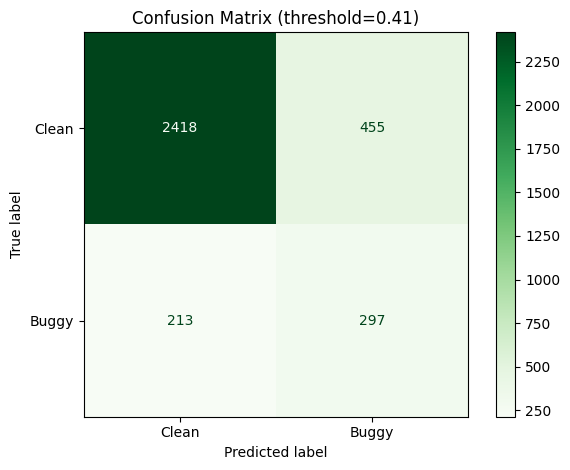

              precision    recall  f1-score   support

       Clean       0.92      0.84      0.88      2873
       Buggy       0.39      0.58      0.47       510

    accuracy                           0.80      3383
   macro avg       0.66      0.71      0.67      3383
weighted avg       0.84      0.80      0.82      3383



In [7]:
y_final = (test_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_final)
disp = ConfusionMatrixDisplay(cm, display_labels=["Clean", "Buggy"])
disp.plot(cmap="Greens")
plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_final, target_names=["Clean", "Buggy"]))

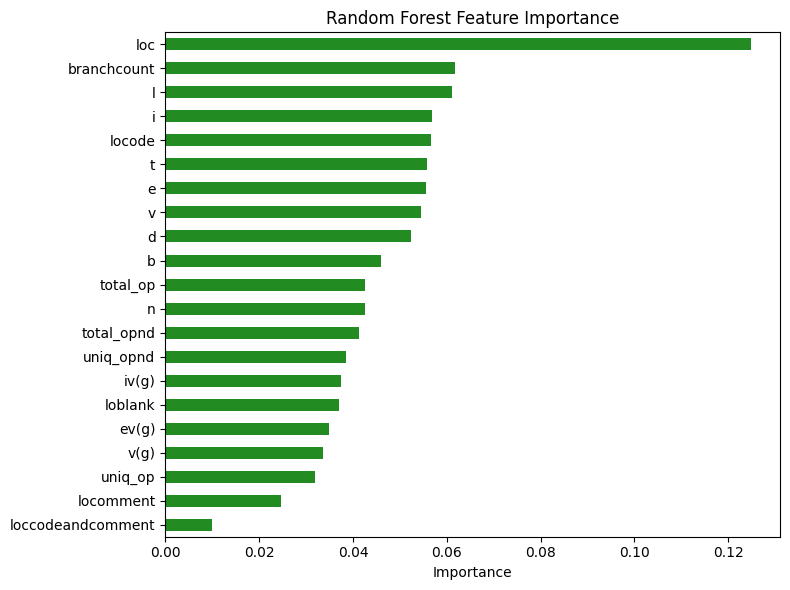

In [8]:
# Feature importance
importance = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
importance.plot.barh(color="forestgreen")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Train Final Model on ALL Data + Predict Blind Test

In [9]:
# Retrain on ALL combined data with SMOTE
X_all_res, y_all_res = smote.fit_resample(X, y)
final_rf = RandomForestClassifier(
    **study.best_params, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
final_rf.fit(X_all_res, y_all_res)
print(f"Final model trained on {len(X_all_res)} SMOTE-resampled samples.")

# Load blind test
blind_df = pd.read_csv("test-blind/test-blind/kc2_test_blind.csv", skiprows=[1, 2])
blind_df.columns = blind_df.columns.str.strip().str.lower().str.replace(" ", "")

for col in FEATURE_COLS:
    if col not in blind_df.columns:
        blind_df[col] = 0
        print(f"  Column '{col}' missing — filled with 0")

X_blind = blind_df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce")
for col in FEATURE_COLS:
    if X_blind[col].isnull().any():
        X_blind[col] = X_blind[col].fillna(X[col].median())

# Predict with optimal threshold
blind_proba = final_rf.predict_proba(X_blind)[:, 1]
blind_preds = (blind_proba >= best_threshold).astype(int)

predictions_df = pd.DataFrame({
    "id": range(len(blind_preds)),
    "defects": blind_preds,
})

print(f"\nThreshold: {best_threshold:.2f}")
print(f"Predictions: {dict(pd.Series(blind_preds).value_counts())}")
predictions_df.head(10)

Final model trained on 28722 SMOTE-resampled samples.
  Column 'loccodeandcomment' missing — filled with 0

Threshold: 0.41
Predictions: {0: np.int64(356), 1: np.int64(164)}


,id,defects
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1
5,5,0
6,6,0
7,7,0
8,8,0
9,9,0


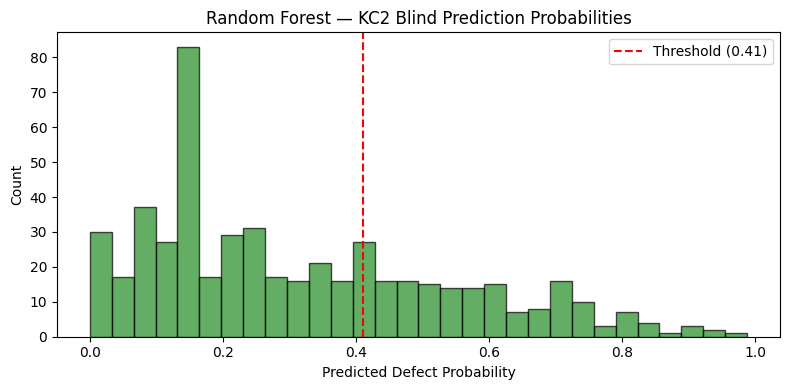

In [10]:
# Probability distribution
plt.figure(figsize=(8, 4))
plt.hist(blind_proba, bins=30, color="forestgreen", edgecolor="black", alpha=0.7)
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Threshold ({best_threshold:.2f})")
plt.xlabel("Predicted Defect Probability")
plt.ylabel("Count")
plt.title("Random Forest — KC2 Blind Prediction Probabilities")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Save submission
output_path = "kc2_blind_predictions_rf.csv"
predictions_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print(predictions_df.head().to_string(index=False))

Saved to kc2_blind_predictions_rf.csv
 id  defects
  0        1
  1        1
  2        1
  3        1
  4        1
